This notebook shows the exploratory data analysis from the preprocessed data.

1. Loading in the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/air_quality_project_dataset.csv")

2. Correlation Matrix

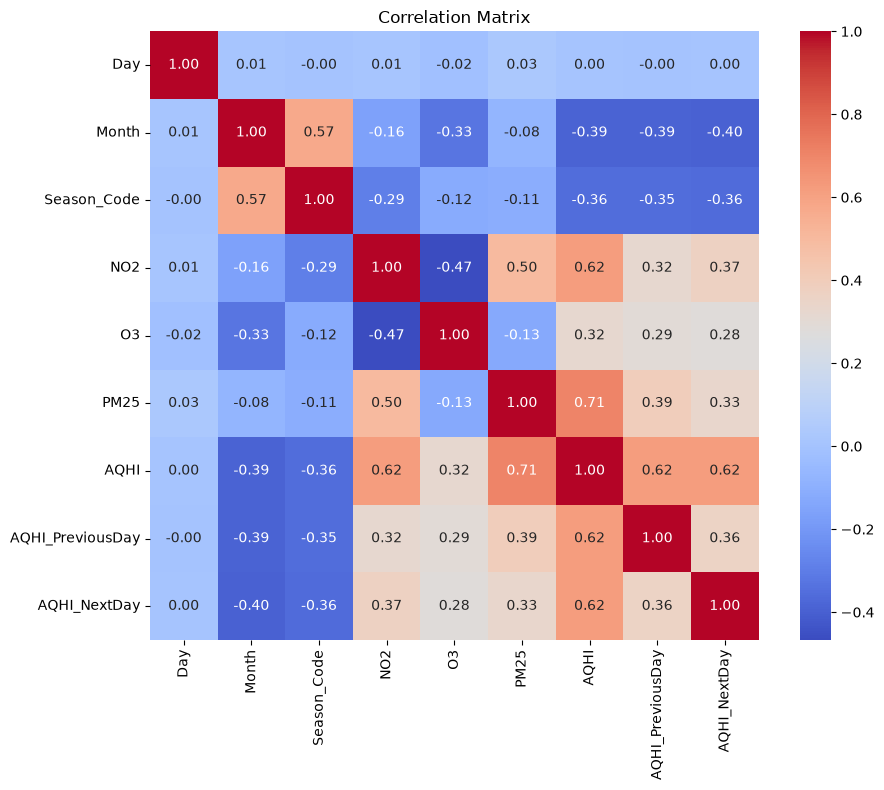


Correlation matrix:
                       Day     Month  Season_Code       NO2        O3  \
Day               1.000000  0.010040    -0.001581  0.008998 -0.018577   
Month             0.010040  1.000000     0.574305 -0.161418 -0.327441   
Season_Code      -0.001581  0.574305     1.000000 -0.294805 -0.123375   
NO2               0.008998 -0.161418    -0.294805  1.000000 -0.467376   
O3               -0.018577 -0.327441    -0.123375 -0.467376  1.000000   
PM25              0.026180 -0.075144    -0.107303  0.498339 -0.125690   
AQHI              0.003000 -0.390423    -0.355791  0.620764  0.321488   
AQHI_PreviousDay -0.000655 -0.387487    -0.353520  0.322430  0.290346   
AQHI_NextDay      0.003324 -0.395886    -0.359698  0.370793  0.283255   

                      PM25      AQHI  AQHI_PreviousDay  AQHI_NextDay  
Day               0.026180  0.003000         -0.000655      0.003324  
Month            -0.075144 -0.390423         -0.387487     -0.395886  
Season_Code      -0.107303 -0.35579

In [ ]:
corr = df[["Day", "Month", "Season_Code", "NO2", "O3", "PM25",
            "AQHI", "AQHI_PreviousDay", "AQHI_NextDay"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
print(corr)

Notes from the correlation matrix

*   The current AQHI seems to have a strong correlation with     AQHI_Next_Day and AQHI_Previous_Day (0.62)

*   PM2.5 has a strong correlation with current AQHI (0.71), but not nearly as much with AQHI_Next_Day (0.33).

*   The pollutant and AQHI_Prev_Day features only have small correlation with the target (AQHI_Next_Day).

*   The day feature did not have any impact/correlation with the target.

*   The months and seasons features had a negative correlation, meaning that they move in the opposite direction. So, as the months/seasons increase, the AQHI_Next_Day decreases.


Conclusion: This may explain why the Linear Regression baseline and Linear Regression with lag had very similar results. AQHI_Next_Day is strongly correlated with the current AQHI.


3. Graphing the target and its most correlated features

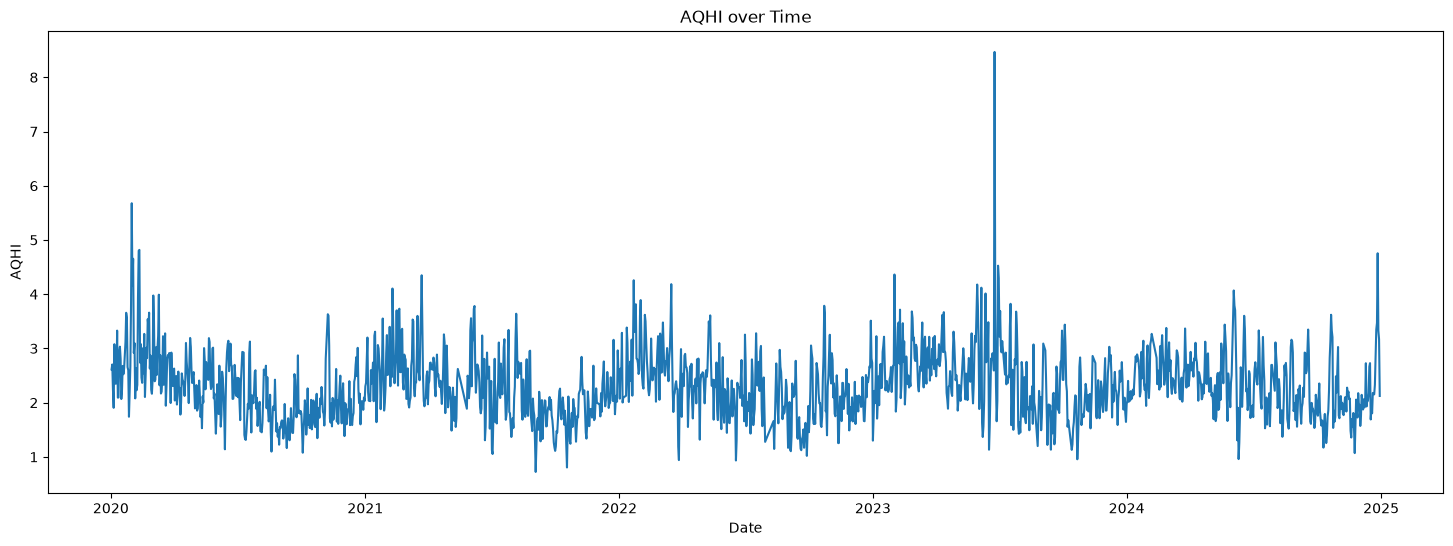

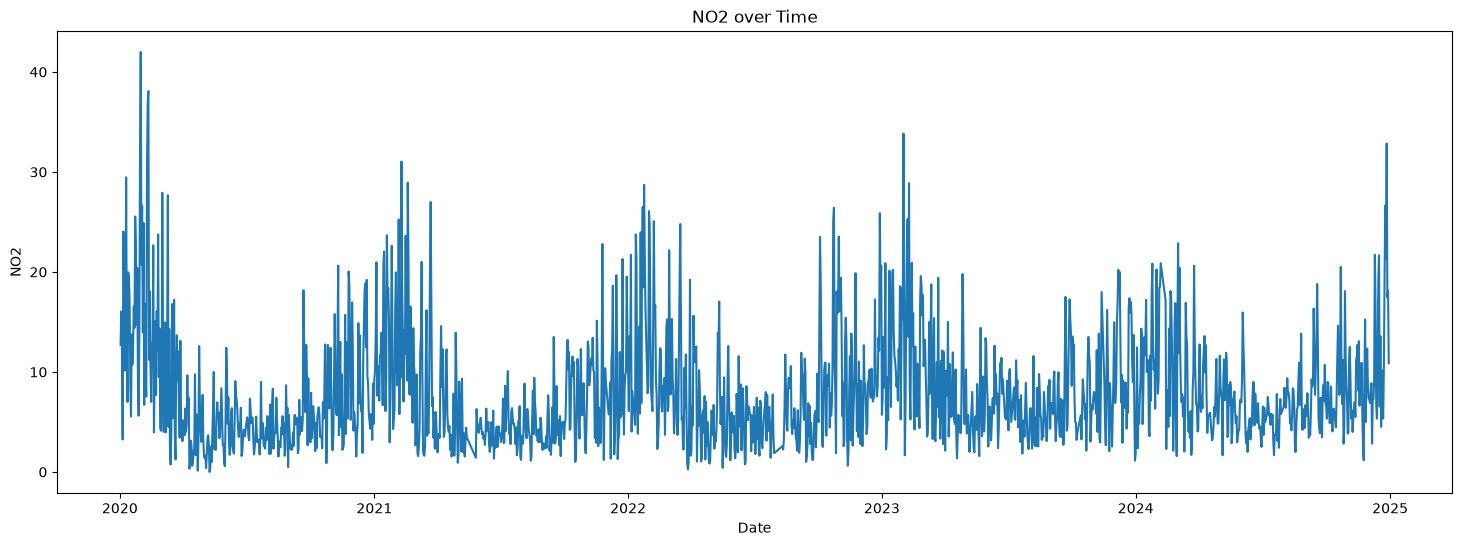

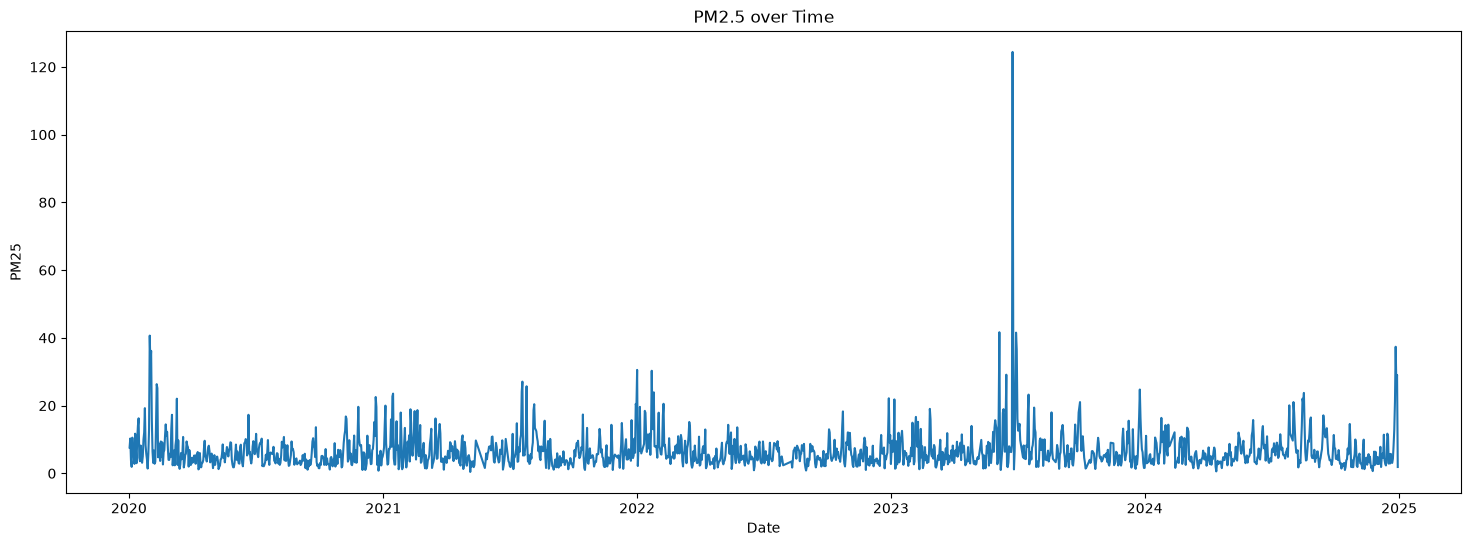

In [ ]:
#Source used for the general plotting structure: https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/
#Source used for the parse_dates and other function features: https://www.datacamp.com/tutorial/pandas-read-csv?utm_cid=23487274749&utm_aid=192541861336&utm_campaign=230119_1-ps-dscia~dsa-tofu~python_2-b2c_3-nam_4-prc_5-na_6-na_7-le_8-pdsh-go_9-nb-e_10-na_11-na&utm_loc=9000501-&utm_mtd=-c&utm_kw=&utm_source=google&utm_medium=paid_search&utm_content=ps-dscia~nam-en~dsa~tofu~tutorial~python&gad_source=1&gad_campaignid=23487274749&gbraid=0AAAAADQ9WsESqo0SSw5Opi1II4NwAgi-0&gclid=CjwKCAjw9NjRBhATEiwA_p2J8XbbX7tjChAuIygCFhL0u74ZdPn2a68xlfbHncSfPPEhAoYp7Eov_xoC9wsQAvD_BwE


import pandas
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/air_quality_project_dataset.csv", usecols=["AQHI", "Date"], parse_dates=["Date"], engine="python")
plt.figure(figsize=(18, 6)) #Making the graph larger for better visibility
plt.plot(df["Date"], df["AQHI"])
plt.title("AQHI over Time")
plt.xlabel("Date")
plt.ylabel("AQHI")
plt.show()

df = pd.read_csv("../data/processed/air_quality_project_dataset.csv", usecols=["NO2", "Date"], parse_dates=["Date"], engine="python")
plt.figure(figsize=(18, 6)) #Making the graph larger for better visibility
plt.plot(df["Date"], df["NO2"])
plt.title("NO2 over Time")
plt.xlabel("Date")
plt.ylabel("NO2")
plt.show()

df = pd.read_csv("../data/processed/air_quality_project_dataset.csv", usecols=["PM25", "Date"], parse_dates=["Date"], engine="python")
plt.figure(figsize=(18, 6)) #Making the graph larger for better visibility
plt.plot(df["Date"], df["PM25"])
plt.title("PM2.5 over Time")
plt.xlabel("Date")
plt.ylabel("PM25")
plt.show()


Notes from the graphs:

*  The AQHI data seems stable, but may show some seasonality trends.

*  The NO2 data seems to have a seasonality trend

*  The PM2.5 data seems stable, with a couple of high peaks.


Conclusion: The overall data seems relatively stationary, but checks should be done, such as:
- Rolling mean is approximately constant over time.
- Rolling standard variation is approximately constant over time.
- ACF (and PACF) plot is approximately constant over time.

4. Showing rolling mean and standard variation checks

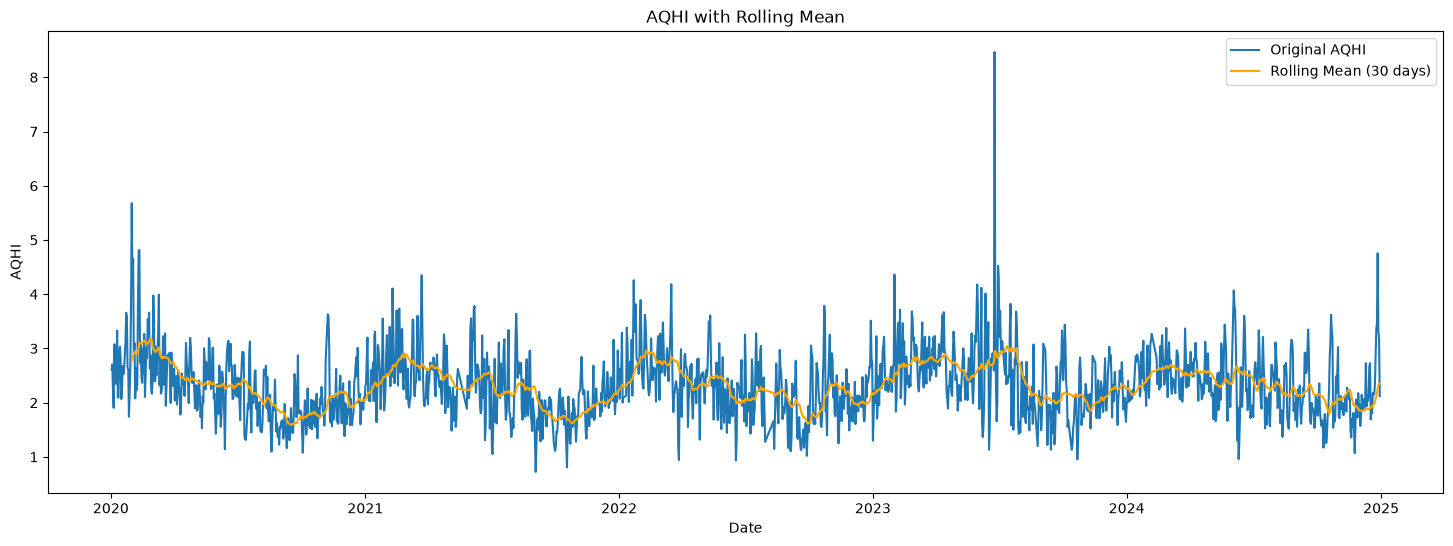

Rolling mean values:
Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-04         NaN
2020-01-05         NaN
2020-01-06         NaN
                ...   
2020-04-06    2.610305
2020-04-07    2.596433
2020-04-08    2.563618
2020-04-09    2.506306
2020-04-10    2.488298
Name: AQHI, Length: 100, dtype: float64


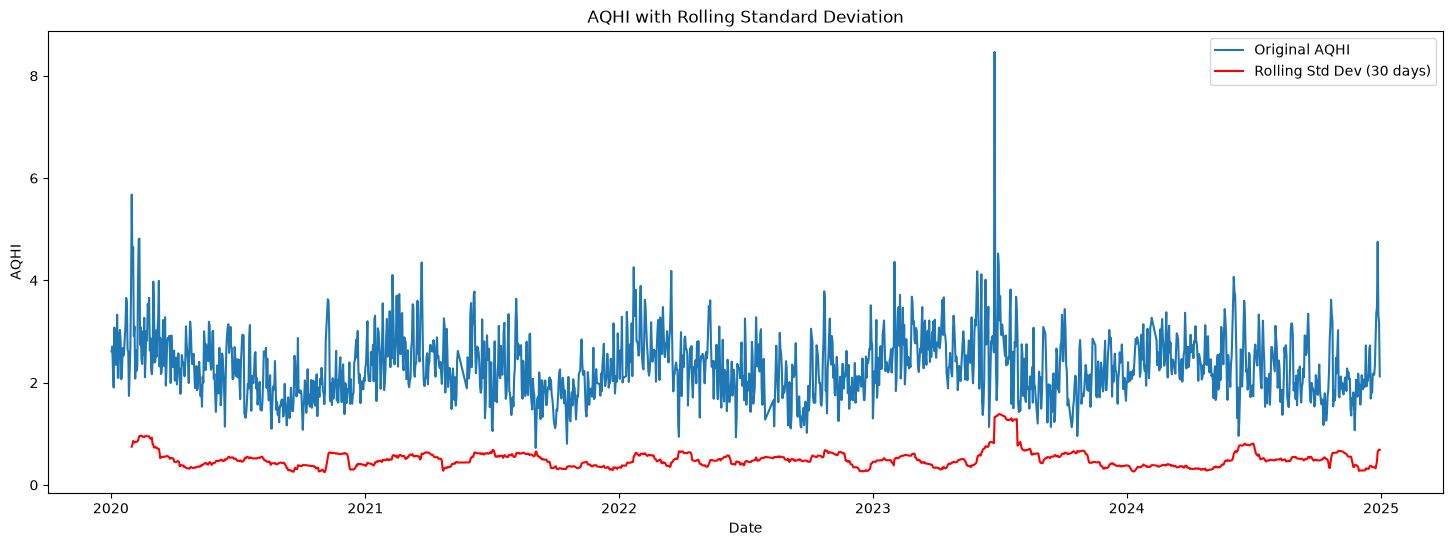

Rolling standard deviation values:
Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-04         NaN
2020-01-05         NaN
2020-01-06         NaN
                ...   
2020-04-06    0.467231
2020-04-07    0.461740
2020-04-08    0.449840
2020-04-09    0.362830
2020-04-10    0.385097
Name: AQHI, Length: 100, dtype: float64


In [28]:
#We'll first make a copy of the dataset to work with for rolling mean and rolling standard deviation calculations, so that we can keep the original dataset intact for later use.
df = pd.read_csv("../data/processed/air_quality_project_dataset.csv", parse_dates=["Date"], engine="python")
df_copy = df.copy()
df_copy.set_index("Date", inplace=True) #Setting the Date column as the index for easier rolling calculations. Source: https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-set_index/
rolling_mean = df_copy["AQHI"].rolling(window=30).mean() #Calculating. Source: https://stackoverflow.com/questions/43437657/rolling-mean-on-pandas-on-a-specific-column

plt.figure(figsize=(18, 6)) #Making the graph larger for better visibility
plt.plot(df_copy.index, df_copy["AQHI"], label="Original AQHI")
plt.plot(df_copy.index, rolling_mean, label="Rolling Mean (30 days)", color="orange")
plt.title("AQHI with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("AQHI")
plt.legend()
plt.show()

print("Rolling mean values:")
print(rolling_mean.head(100)) #Printing the first 100 rows of the rolling mean values to see the initial trend and how it evolves over time.

#The same procedure will be done for the rolling standard deviation.
rolling_std = df_copy["AQHI"].rolling(window=30).std() #Calculating.
plt.figure(figsize=(18, 6)) #Making the graph larger for better visibility
plt.plot(df_copy.index, df_copy["AQHI"], label="Original AQHI")
plt.plot(df_copy.index, rolling_std, label="Rolling Std Dev (30 days)", color="red")
plt.title("AQHI with Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("AQHI")
plt.legend()
plt.show()

print("Rolling standard deviation values:")
print(rolling_std.head(100)) #Printing the first 100 rows of the rolling standard deviation values to see the initial trend and how it evolves over time.
